# PBMC Single-Cell RNA-seq Analysis: A Complete Workflow

This tutorial demonstrates a comprehensive workflow for preprocessing and analyzing single-cell RNA sequencing data from Peripheral Blood Mononuclear Cells (PBMCs). We follow best practices from the community and provide references to key resources throughout.

## Workflow Overview

1. **Quality control** - Filtering cells and genes based on key metrics
2. **Normalization** - Correcting for technical variation between cells
3. **Feature selection** - Identifying informative genes for downstream analysis
4. **Dimensionality reduction** - Using PCA, UMAP, and diffusion maps
5. **Clustering** - Identifying groups of similar cells with Leiden algorithm
6. **Doublet detection** - Finding artifacts from two cells captured as one
7. **Cell type annotation** - Assigning biological identities to cell clusters

## Key References

- **Single-cell best practices book**: [https://www.sc-best-practices.org/](https://www.sc-best-practices.org/)
  - [Preprocessing & Visualization](https://www.sc-best-practices.org/preprocessing_visualization/quality_control.html)
  - [Clustering](https://www.sc-best-practices.org/cellular_structure/clustering.html)
  - [Cell type annotation](https://www.sc-best-practices.org/cell_annotation/introduction.html)
- **Single-cell primers repository**: [https://github.com/settylab/single-cell-primers](https://github.com/settylab/single-cell-primers)
- **Scanpy tutorials**: [https://scanpy-tutorials.readthedocs.io/](https://scanpy-tutorials.readthedocs.io/)

## Environment Setup

Before starting, ensure you have the required packages installed:
```bash
uv pip install scanpy palantir matplotlib
```

For more details, see the `Setup.md` file in this repository.

## Import Libraries

In [1]:
import os
import numpy as np
import pandas as pd
import anndata
import scanpy as sc
import palantir

import matplotlib
import matplotlib.pyplot as plt

### Configure Plotting Settings

Feel free to adjust these to your preference:

In [2]:
# Display plots inline in Jupyter
%matplotlib inline

# Set default figure parameters
matplotlib.rcParams["figure.figsize"] = [4, 4]
matplotlib.rcParams["figure.dpi"] = 100
matplotlib.rcParams["image.cmap"] = "Spectral_r"

# Remove plot frames for cleaner visualizations
matplotlib.rcParams["axes.spines.bottom"] = False
matplotlib.rcParams["axes.spines.top"] = False
matplotlib.rcParams["axes.spines.left"] = False
matplotlib.rcParams["axes.spines.right"] = False

# Set Scanpy verbosity (0=errors, 1=warnings, 2=info, 3=hints)
sc.settings.verbosity = 2

## Parameters

These are the main parameters for this analysis. Adjust the file paths to match your dataset location:

In [3]:
# Input: CellRanger output (10X Genomics format)
input_h5_file = "data/pbmc_10k_protein_v3_filtered_feature_bc_matrix.h5"

# Output: Processed AnnData object
output_h5ad_file = "data/pbmc_10x_rna_processed.h5ad"

---

# 1. Loading the Data

We start by loading the single-cell RNA-seq data from a 10X Genomics dataset. The data is stored in HDF5 format, which is efficient for large datasets.

**📖 Best practices reference**: [Data loading](https://www.sc-best-practices.org/preprocessing_visualization/data_loading.html)

In [4]:
# Load 10X data with optional backup URL for the tutorial example
tutorial_example_data = (
    "https://fh-pi-setty-m-eco-public.s3.us-west-2.amazonaws.com/"
    "single-cell-primers/scrna/pbmc_10k_protein_v3_filtered_feature_bc_matrix.h5"
)

# Note: Remove backup_url parameter when using your own data
adata = sc.read_10x_h5(input_h5_file, backup_url=tutorial_example_data)

print(f"Loaded dataset: {adata.n_obs} cells × {adata.n_vars} features")
adata

reading data/pbmc_10k_protein_v3_filtered_feature_bc_matrix.h5
 (0:00:00)
Loaded dataset: 7865 cells × 33538 features


/Users/dotto/Documents/blender_notebooks/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1793: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/dotto/Documents/blender_notebooks/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1793: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 7865 × 33538
    var: 'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence'

### Handle Duplicate Gene Names

Scanpy warns that "Variable names are not unique." This is because some genes share the same gene symbol despite having unique Ensembl IDs. We need to make gene names unique for downstream processing.

**Strategy**: Store original gene names separately, then create unique identifiers.

In [5]:
# Inspect the feature annotation
print("Feature annotations (first 5):")
print(adata.var.head())

# Check for duplicates
duplicate_genes = adata.var_names[adata.var_names.duplicated()].unique()
print(f"\nFound {len(duplicate_genes)} duplicate gene names")
if len(duplicate_genes) > 0:
    print("Examples:", duplicate_genes[:5].tolist())

Feature annotations (first 5):
                    gene_ids    feature_types  genome pattern read sequence
MIR1302-2HG  ENSG00000243485  Gene Expression  GRCh38                      
FAM138A      ENSG00000237613  Gene Expression  GRCh38                      
OR4F5        ENSG00000186092  Gene Expression  GRCh38                      
AL627309.1   ENSG00000238009  Gene Expression  GRCh38                      
AL627309.3   ENSG00000239945  Gene Expression  GRCh38                      

Found 24 duplicate gene names
Examples: ['RGS5', 'TBCE', 'PDE11A', 'LINC01238', 'PRSS50']


In [6]:
# Store original gene names
adata.var["gene_name"] = adata.var_names

# Make gene names unique (adds -1, -2, etc. to duplicates)
adata.var_names_make_unique()

print("Gene names are now unique!")
print("\nExample of renamed genes:")
print(adata.var[adata.var["gene_name"].duplicated(keep=False)].head(10))

Gene names are now unique!

Example of renamed genes:
                    gene_ids    feature_types  genome pattern read sequence  \
RGS5         ENSG00000143248  Gene Expression  GRCh38                         
RGS5-1       ENSG00000232995  Gene Expression  GRCh38                         
TBCE         ENSG00000285053  Gene Expression  GRCh38                         
TBCE-1       ENSG00000284770  Gene Expression  GRCh38                         
PDE11A       ENSG00000128655  Gene Expression  GRCh38                         
PDE11A-1     ENSG00000284741  Gene Expression  GRCh38                         
LINC01238    ENSG00000237940  Gene Expression  GRCh38                         
LINC01238-1  ENSG00000261186  Gene Expression  GRCh38                         
PRSS50       ENSG00000283706  Gene Expression  GRCh38                         
PRSS50-1     ENSG00000206549  Gene Expression  GRCh38                         

             gene_name  
RGS5              RGS5  
RGS5-1            RGS5  
T

---

# 2. Quality Control (QC)

Quality control is crucial for removing low-quality cells that could confound downstream analysis. We filter cells based on:

1. **Total counts** (library size): Too low = poor capture, too high = potential doublets
2. **Number of genes detected**: Too low = low-quality cell or empty droplet
3. **Mitochondrial content**: High mitochondrial % = stressed/dying cells

**📖 Best practices reference**: [Quality control](https://www.sc-best-practices.org/preprocessing_visualization/quality_control.html)

### Calculate QC Metrics

In [7]:
# Identify mitochondrial genes (start with 'MT-')
adata.var["mt"] = adata.var_names.str.startswith("MT-")

# Calculate QC metrics
# This adds several columns to adata.obs and adata.var
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt"],  # Calculate % mitochondrial reads
    percent_top=None,  # Don't calculate top gene percentages (optional)
    log1p=False,  # Don't log-transform the metrics yet
    inplace=True  # Modify adata in place
)

print("QC metrics calculated!")
print("\nNew cell-level metrics (obs):")
adata.obs.head(5)

QC metrics calculated!

New cell-level metrics (obs):


,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt
AAACCCAAGATTGTGA-1,2194,6160.0,523.0,8.490260
AAACCCACATCGGTTA-1,2093,6713.0,415.0,6.182034
AAACCCAGTACCGCGT-1,1518,3637.0,287.0,7.891119
AAACCCAGTATCGAAA-1,737,1244.0,110.0,8.842443
AAACCCAGTCGTCATA-1,1240,2611.0,156.0,5.974722


In [8]:
# Summary statistics
print("QC Metrics Summary:")
print(adata.obs[["total_counts", "n_genes_by_counts", "pct_counts_mt"]].describe())

# Add log10 counts for better visualizations
adata.obs["log10_total_counts"] = np.log10(adata.obs["total_counts"])

QC Metrics Summary:
       total_counts  n_genes_by_counts  pct_counts_mt
count   7865.000000        7865.000000    7865.000000
mean    4703.801758        1585.174698       6.485864
std     4306.967773         675.503957       4.224884
min      501.000000          19.000000       0.000000
25%     2901.000000        1190.000000       4.841270
50%     3648.000000        1394.000000       5.920444
75%     5156.000000        1819.000000       7.229673
max    73579.000000        6878.000000      98.588715


### Filter Cells Based on RNA Content

We examine the distribution of total molecule counts (UMIs) per cell and remove outliers.

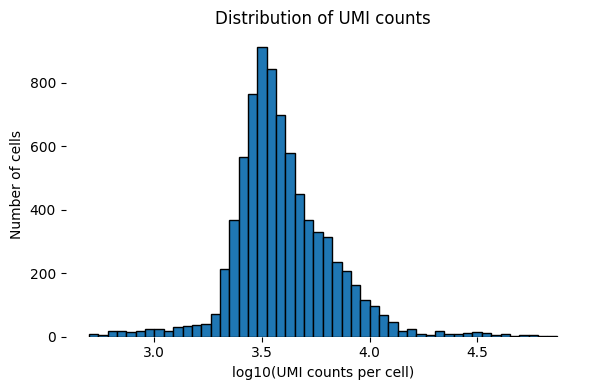

In [9]:
# Visualize distribution of total counts
plt.figure(figsize=(6, 4))
ax = plt.gca()
ax.hist(adata.obs["log10_total_counts"], bins=50, edgecolor="black")
ax.set_xlabel("log10(UMI counts per cell)")
ax.set_ylabel("Number of cells")
ax.set_title("Distribution of UMI counts")
plt.tight_layout()
plt.show()

**Interpretation**: 
- Cells with very low counts are likely empty droplets or low-quality cells
- Cells with very high counts may be doublets (two cells in one droplet)

We'll use percentile-based thresholds to filter outliers:

Lower threshold: 1595 UMIs
Upper threshold: 13434 UMIs


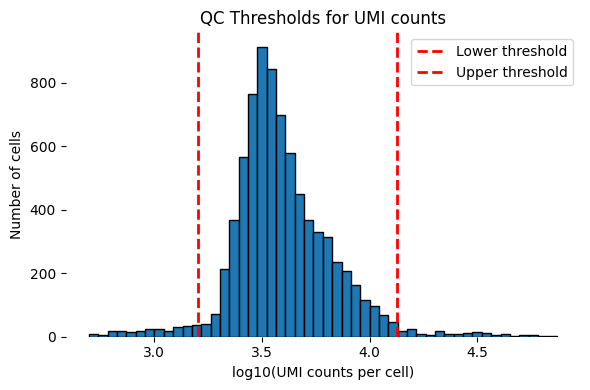

In [10]:
# Set thresholds at 3rd and 98th percentiles
THRESHOLDS = np.log10(np.percentile(adata.obs["total_counts"], [3, 98]))

print(f"Lower threshold: {10**THRESHOLDS[0]:.0f} UMIs")
print(f"Upper threshold: {10**THRESHOLDS[1]:.0f} UMIs")

# Visualize thresholds
plt.figure(figsize=(6, 4))
ax = plt.gca()
ax.hist(adata.obs["log10_total_counts"], bins=50, edgecolor="black")
ax.axvline(THRESHOLDS[0], color="red", linestyle="--", linewidth=2, label="Lower threshold")
ax.axvline(THRESHOLDS[1], color="red", linestyle="--", linewidth=2, label="Upper threshold")
ax.set_xlabel("log10(UMI counts per cell)")
ax.set_ylabel("Number of cells")
ax.set_title("QC Thresholds for UMI counts")
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
# Apply filtering
cells_before = adata.n_obs

adata = adata[
    (adata.obs["log10_total_counts"] > THRESHOLDS[0]) &
    (adata.obs["log10_total_counts"] < THRESHOLDS[1]),
    :
].copy()

cells_after = adata.n_obs
print(f"Filtered {cells_before - cells_after} cells ({100*(cells_before - cells_after)/cells_before:.1f}%)")
print(f"Remaining: {cells_after} cells")

Filtered 393 cells (5.0%)
Remaining: 7472 cells


### Filter Cells Based on Mitochondrial Content

High mitochondrial gene expression often indicates stressed or dying cells, which should be removed.

**📖 Best practices reference**: [Mitochondrial filtering](https://www.sc-best-practices.org/preprocessing_visualization/quality_control.html#mitochondrial-genes)

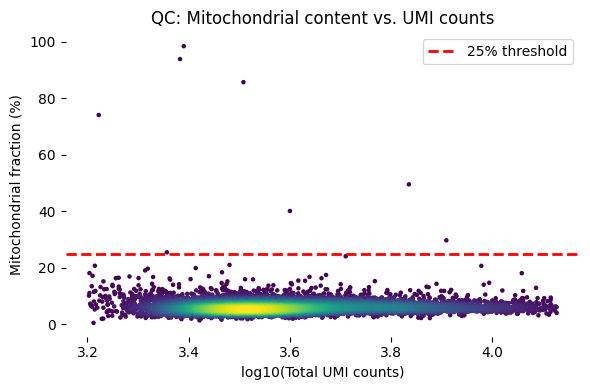

Cells above 25% MT: 8


In [12]:
# Visualize relationship between total counts and mitochondrial percentage
x, y, dens = palantir.plot.density_2d(
    adata.obs["log10_total_counts"],
    adata.obs["pct_counts_mt"]
)

MITO_THRESHOLD = 25  # 25% mitochondrial content

plt.figure(figsize=(6, 4))
ax = plt.gca()
ax.scatter(x, y, c=dens, s=5, cmap="viridis")
ax.axhline(MITO_THRESHOLD, color="red", linestyle="--", linewidth=2, label=f"{MITO_THRESHOLD}% threshold")
ax.set_xlabel("log10(Total UMI counts)")
ax.set_ylabel("Mitochondrial fraction (%)")
ax.set_title("QC: Mitochondrial content vs. UMI counts")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Cells above {MITO_THRESHOLD}% MT: {(adata.obs['pct_counts_mt'] >= MITO_THRESHOLD).sum()}")

In [13]:
# Apply mitochondrial filter
cells_before = adata.n_obs

adata = adata[adata.obs["pct_counts_mt"] < MITO_THRESHOLD, :].copy()

cells_after = adata.n_obs
print(f"Filtered {cells_before - cells_after} cells ({100*(cells_before - cells_after)/cells_before:.1f}%)")
print(f"Remaining: {cells_after} cells")

Filtered 8 cells (0.1%)
Remaining: 7464 cells


In [14]:
# Final QC summary
print("\n=== Final Dataset After QC ===")
adata


=== Final Dataset After QC ===


AnnData object with n_obs × n_vars = 7464 × 33538
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'log10_total_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence', 'gene_name', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'

---

# 3. Preprocessing and Normalization

After QC, we normalize the data to make cells comparable. We also preserve intermediate processing steps in separate layers for later use.

**📖 Best practices reference**: [Normalization](https://www.sc-best-practices.org/preprocessing_visualization/normalization.html)

### Gene Filtering

Remove genes detected in very few cells (likely noise):

In [15]:
genes_before = adata.n_vars

# Keep genes expressed in at least 50 cells
sc.pp.filter_genes(adata, min_cells=50)

genes_after = adata.n_vars
print(f"Filtered {genes_before - genes_after} genes ({100*(genes_before - genes_after)/genes_before:.1f}%)")
print(f"Remaining: {genes_after} genes")

filtered out 21645 genes that are detected in less than 50 cells
Filtered 21645 genes (64.5%)
Remaining: 11893 genes


### Normalization and Log-Transformation

**Why normalize?** Different cells have different sequencing depths. Normalization accounts for this technical variation.

**Steps**:
1. **Library size normalization**: Scale each cell to the same total count (e.g., 10,000)
2. **Log-transformation**: Stabilize variance and reduce skewness

We store each processing step as a separate layer for reproducibility and flexibility.

In [16]:
# Store raw counts
adata.layers["raw_counts"] = adata.X.copy()

# Normalize to 10,000 counts per cell
sc.pp.normalize_total(adata, target_sum=1e4)

# Store normalized counts
adata.layers["normalized_counts"] = adata.X.copy()

# Log-transform: log(x + 1)
palantir.preprocess.log_transform(adata)

# Store log-transformed counts (this is now our main X)
adata.layers["logcounts"] = adata.X.copy()

print("Normalization complete!")
print(f"\nAvailable layers: {list(adata.layers.keys())}")

normalizing counts per cell
    finished (0:00:00)
Normalization complete!

Available layers: ['raw_counts', 'normalized_counts', 'logcounts']


---

# 4. Feature Selection: Highly Variable Genes

Not all genes are equally informative. We identify **highly variable genes (HVGs)** that capture biological variation rather than technical noise.

**Why?** Focusing on HVGs:
- Reduces computational burden
- Improves signal-to-noise ratio
- Enhances clustering and visualization

**📖 Best practices reference**: [Feature selection](https://www.sc-best-practices.org/preprocessing_visualization/feature_selection.html)

extracting highly variable genes
    finished (0:00:00)
Identified 2500 highly variable genes


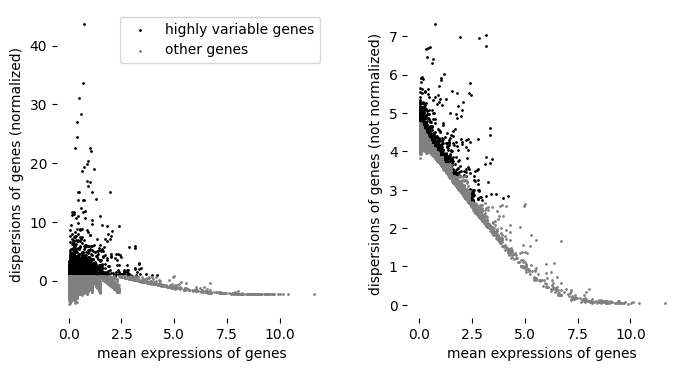

In [17]:
# Identify top 2500 highly variable genes using CellRanger method
# (method from Zheng et al. Nature Communications 2017)
sc.pp.highly_variable_genes(
    adata,
    flavor="cell_ranger",
    n_top_genes=2500
)

print(f"Identified {adata.var['highly_variable'].sum()} highly variable genes")

# Visualize HVGs
sc.pl.highly_variable_genes(adata)

**Interpretation**: 
- **x-axis**: Mean expression level
- **y-axis**: Dispersion (variance / mean)
- **Red points**: Highly variable genes selected for downstream analysis

---

# 5. Dimensionality Reduction

Single-cell datasets are high-dimensional (thousands of genes). We use dimensionality reduction to:
1. Denoise the data
2. Enable visualization
3. Speed up downstream computations

**📖 Best practices reference**: [Dimensionality reduction](https://www.sc-best-practices.org/preprocessing_visualization/dimensionality_reduction.html)

### Principal Component Analysis (PCA)

PCA finds linear combinations of genes (principal components) that explain the most variance.

**Note**: Choosing the number of PCs is important. Here we use 50, but ideally you'd examine the explained variance ratio to find the "elbow" point.

In [18]:
# Compute 50 principal components using HVGs
sc.pp.pca(adata, n_comps=50, use_highly_variable=True)

print("PCA complete!")
print(f"Shape of PCA representation: {adata.obsm['X_pca'].shape}")

computing PCA
    with n_comps=50


/Users/dotto/Documents/blender_notebooks/.venv/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:227: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


    finished (0:00:00)
PCA complete!
Shape of PCA representation: (7464, 50)


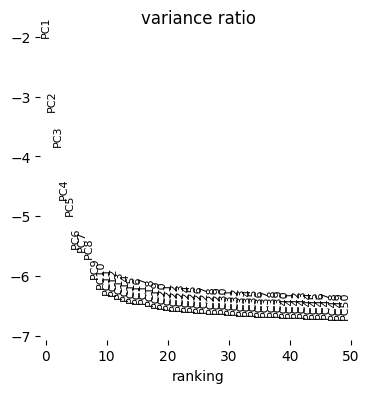

In [19]:
# Visualize explained variance
sc.pl.pca_variance_ratio(adata, log=True, n_pcs=50)

### UMAP (Uniform Manifold Approximation and Projection)

UMAP is a non-linear dimensionality reduction method that preserves both local and global structure. It's the current standard for visualizing single-cell data.

**How it works**:
1. Compute a k-nearest neighbor graph in PCA space
2. Project to 2D while preserving neighbor relationships

In [20]:
# Compute k-nearest neighbors graph (required for UMAP)
sc.pp.neighbors(adata, n_neighbors=15, use_rep="X_pca")

# Compute UMAP embedding
sc.tl.umap(adata)

print("UMAP complete!")
print(f"Shape of UMAP embedding: {adata.obsm['X_umap'].shape}")

computing neighbors


/Users/dotto/Documents/blender_notebooks/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


    finished (0:00:01)
computing UMAP
    finished (0:00:06)
UMAP complete!
Shape of UMAP embedding: (7464, 2)


### Diffusion Maps

Diffusion maps capture non-linear structure and are particularly useful for:
- Identifying developmental trajectories
- Modeling cellular transitions
- Gene-expression imputation
- Computing cell-state density

**Reference**: [Palantir documentation](https://palantir.readthedocs.io/)

In [21]:
# Calculate diffusion maps
palantir.utils.run_diffusion_maps(adata)

print("Diffusion maps complete!")
print(f"Diffusion components stored in adata.obsm['DM_EigenVectors']")

computing neighbors
    finished (0:00:00)
Diffusion maps complete!
Diffusion components stored in adata.obsm['DM_EigenVectors']


---

# 6. Clustering

Clustering groups similar cells together, which helps identify cell types and states.

**📖 Best practices reference**: [Clustering](https://www.sc-best-practices.org/cellular_structure/clustering.html)

### Leiden Clustering

The Leiden algorithm is an improvement over Louvain clustering with better guarantees on cluster quality.

**Key parameter**: `resolution` controls cluster granularity (higher = more clusters)

In [22]:
# Perform Leiden clustering
sc.tl.leiden(adata, flavor="igraph", resolution=1.0)

print(f"Identified {adata.obs['leiden'].nunique()} clusters")
print("\nCluster sizes:")
print(adata.obs['leiden'].value_counts().sort_index())

running Leiden clustering
    finished (0:00:00)
Identified 14 clusters

Cluster sizes:
leiden
0      743
1     1050
2      870
3     1296
4     1088
5      555
6      179
7      381
8      454
9       73
10     159
11      71
12     453
13      92
Name: count, dtype: int64


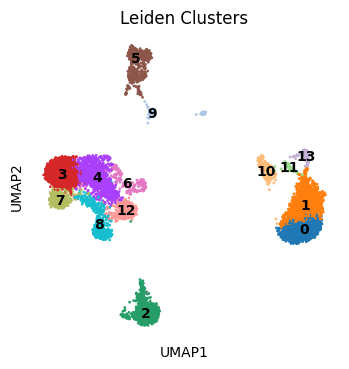

In [23]:
# Visualize clusters on UMAP
sc.pl.umap(adata, color="leiden", legend_loc="on data", title="Leiden Clusters")

### Cell Density Estimation

Computing cell density helps identify regions of high/low cell abundance, which can indicate:
- Common vs. rare cell types
- Potential batch effects
- Areas requiring more careful examination

[2025-10-02 18:24:08,186] [INFO    ] Using sparse Gaussian Process since n_landmarks (5,000) < n_samples (7,464) and rank = 1.0.
[2025-10-02 18:24:08,186] [INFO    ] Computing nearest neighbor distances.
[2025-10-02 18:24:13,296] [INFO    ] Using embedding dimensionality d=10. Use d_method="fractal" to enable effective density normalization.
[2025-10-02 18:24:13,410] [INFO    ] Using covariance function Matern52(ls=0.0022575173061341047).
[2025-10-02 18:24:13,411] [INFO    ] Computing 5,000 landmarks with k-means clustering (random_state=42).
[2025-10-02 18:24:15,956] [INFO    ] Using rank 5,000 covariance representation.
[2025-10-02 18:24:16,665] [INFO    ] Running inference using L-BFGS-B.
[2025-10-02 18:24:18,249] [INFO    ] Computing predictive function.


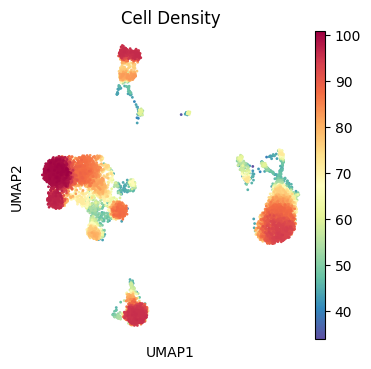

In [24]:
# Calculate cell-state density in diffusion map space
palantir.utils.run_density(adata)

# Visualize density on UMAP
sc.pl.umap(adata, color="mellon_log_density", title="Cell Density")

---

# 7. Doublet Detection with Scrublet

**Doublets** are artifacts where two cells are captured in the same droplet, appearing as a single cell. They can:
- Create artificial cell types
- Confound differential expression analysis
- Distort trajectory inference

**Scrublet** detects doublets by simulating artificial doublets and comparing them to real cells.

**Why we run it here (after UMAP)**: While doublet detection ideally uses raw counts, we run it at this stage so we can immediately visualize the results on our UMAP embedding. This helps us quickly identify which clusters might be doublet-enriched.

**📖 Best practices reference**: [Doublet detection](https://www.sc-best-practices.org/preprocessing_visualization/doublet_detection.html)

**Reference**: Wolock et al. (2019). *Cell Systems*. [Scrublet: computational identification of cell doublets](https://doi.org/10.1016/j.cels.2018.11.005)

In [25]:
# Scrublet works best on raw counts, so we temporarily swap layers

# Temporarily swap to use raw counts
adata.X = adata.layers['raw_counts'].copy()

# Run Scrublet doublet detection on raw counts
sc.pp.scrublet(adata, batch_key=None)

# Swap back to log-transformed data for downstream analyses
adata.X = adata.layers['logcounts']

Running Scrublet
normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
Embedding transcriptomes using PCA...
    using data matrix X directly
Automatically set threshold at doublet score = 0.23
Detected doublet rate = 2.9%
Estimated detectable doublet fraction = 53.3%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 5.5%
    Scrublet finished (0:00:20)


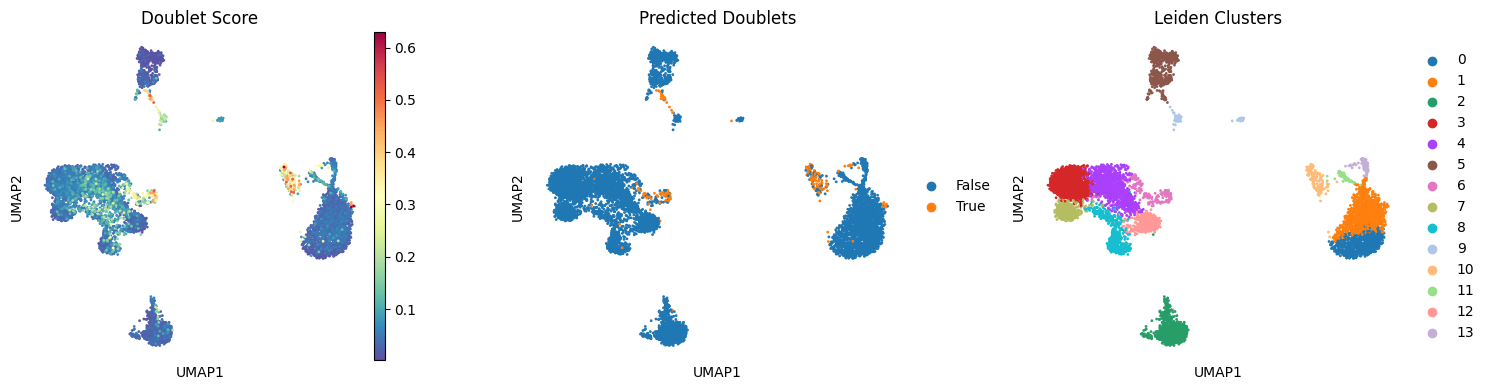

In [26]:
# Visualize doublets on UMAP
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sc.pl.umap(adata, color="doublet_score", ax=axes[0], show=False, title="Doublet Score")
sc.pl.umap(adata, color="predicted_doublet", ax=axes[1], show=False, title="Predicted Doublets")
sc.pl.umap(adata, color="leiden", ax=axes[2], show=False, title="Leiden Clusters")

plt.tight_layout()
plt.show()

**Interpretation**: 
- High doublet scores in specific clusters may indicate those clusters are artifacts
- Consider removing predicted doublets before downstream analysis
- Or at least be aware of them when interpreting results

---

# 8. Imputation with MAGIC

Single-cell data suffers from **dropout events** (genes expressed but not detected). MAGIC imputes missing values using diffusion on the cell similarity graph.

**Reference**: van Dijk et al. (2018). *Cell*. [MAGIC: A diffusion-based imputation method](https://doi.org/10.1016/j.cell.2018.05.061)

In [27]:
# Perform MAGIC imputation
palantir.utils.run_magic_imputation(adata)

print("MAGIC imputation complete!")
print(f"Imputed data stored in layer: 'MAGIC_imputed_data'")

MAGIC imputation complete!
Imputed data stored in layer: 'MAGIC_imputed_data'


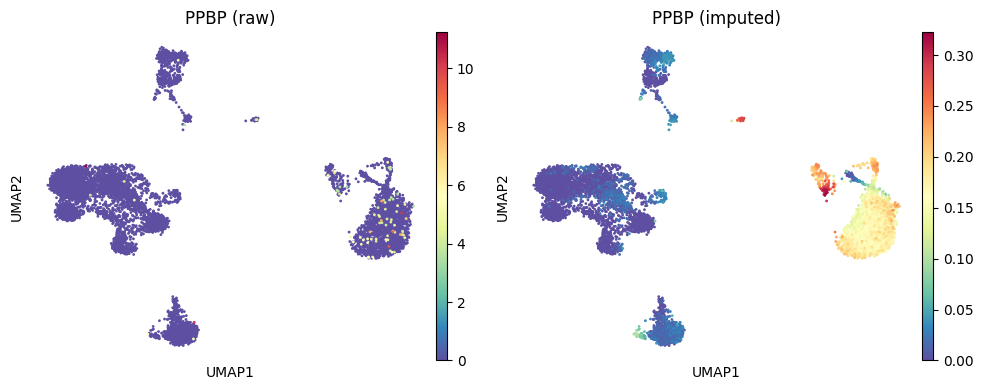

In [40]:
# Compare raw vs. imputed expression for a marker gene
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sc.pl.umap(adata, color="PPBP", layer="logcounts", ax=axes[0], show=False, title="PPBP (raw)")
sc.pl.umap(adata, color="PPBP", layer="MAGIC_imputed_data", ax=axes[1], show=False, title="PPBP (imputed)")

plt.tight_layout()
plt.show()

---

# 9. Cell Type Annotation

We identify cell types based on known marker genes. This requires biological knowledge of expected cell populations in PBMCs.

**📖 Best practices reference**: [Cell type annotation](https://www.sc-best-practices.org/cellular_structure/annotation.html)

### Define Marker Genes

Based on literature and known PBMC biology:

In [29]:
# Canonical PBMC marker genes
marker_genes = pd.Series([
    "CD34",         # Hematopoietic stem/progenitor cells
    "CD3D", "CD3E", # T cells (general)
    "CD4",          # CD4+ T cells
    "CD8A", "CD8B", # CD8+ T cells
    "CCR7", "LEF1", # Naive T cells
    "IL7R",         # CD4+ T cells
    "NKG7", "GNLY", # NK cells
    "FCGR3A",       # CD16+ Monocytes / NK cells
    "CD14", "LYZ",  # CD14+ Monocytes
    "MS4A1", "CD79A",  # B cells
    "FCER1A",       # Dendritic cells
    "PPBP",         # Megakaryocytes
])

# Keep only markers present in dataset
marker_genes = marker_genes[marker_genes.isin(adata.var_names)]

print(f"Using {len(marker_genes)} marker genes")
print(marker_genes.tolist())

Using 17 marker genes
['CD3D', 'CD3E', 'CD4', 'CD8A', 'CD8B', 'CCR7', 'LEF1', 'IL7R', 'NKG7', 'GNLY', 'FCGR3A', 'CD14', 'LYZ', 'MS4A1', 'CD79A', 'FCER1A', 'PPBP']


### Visualize Marker Gene Expression

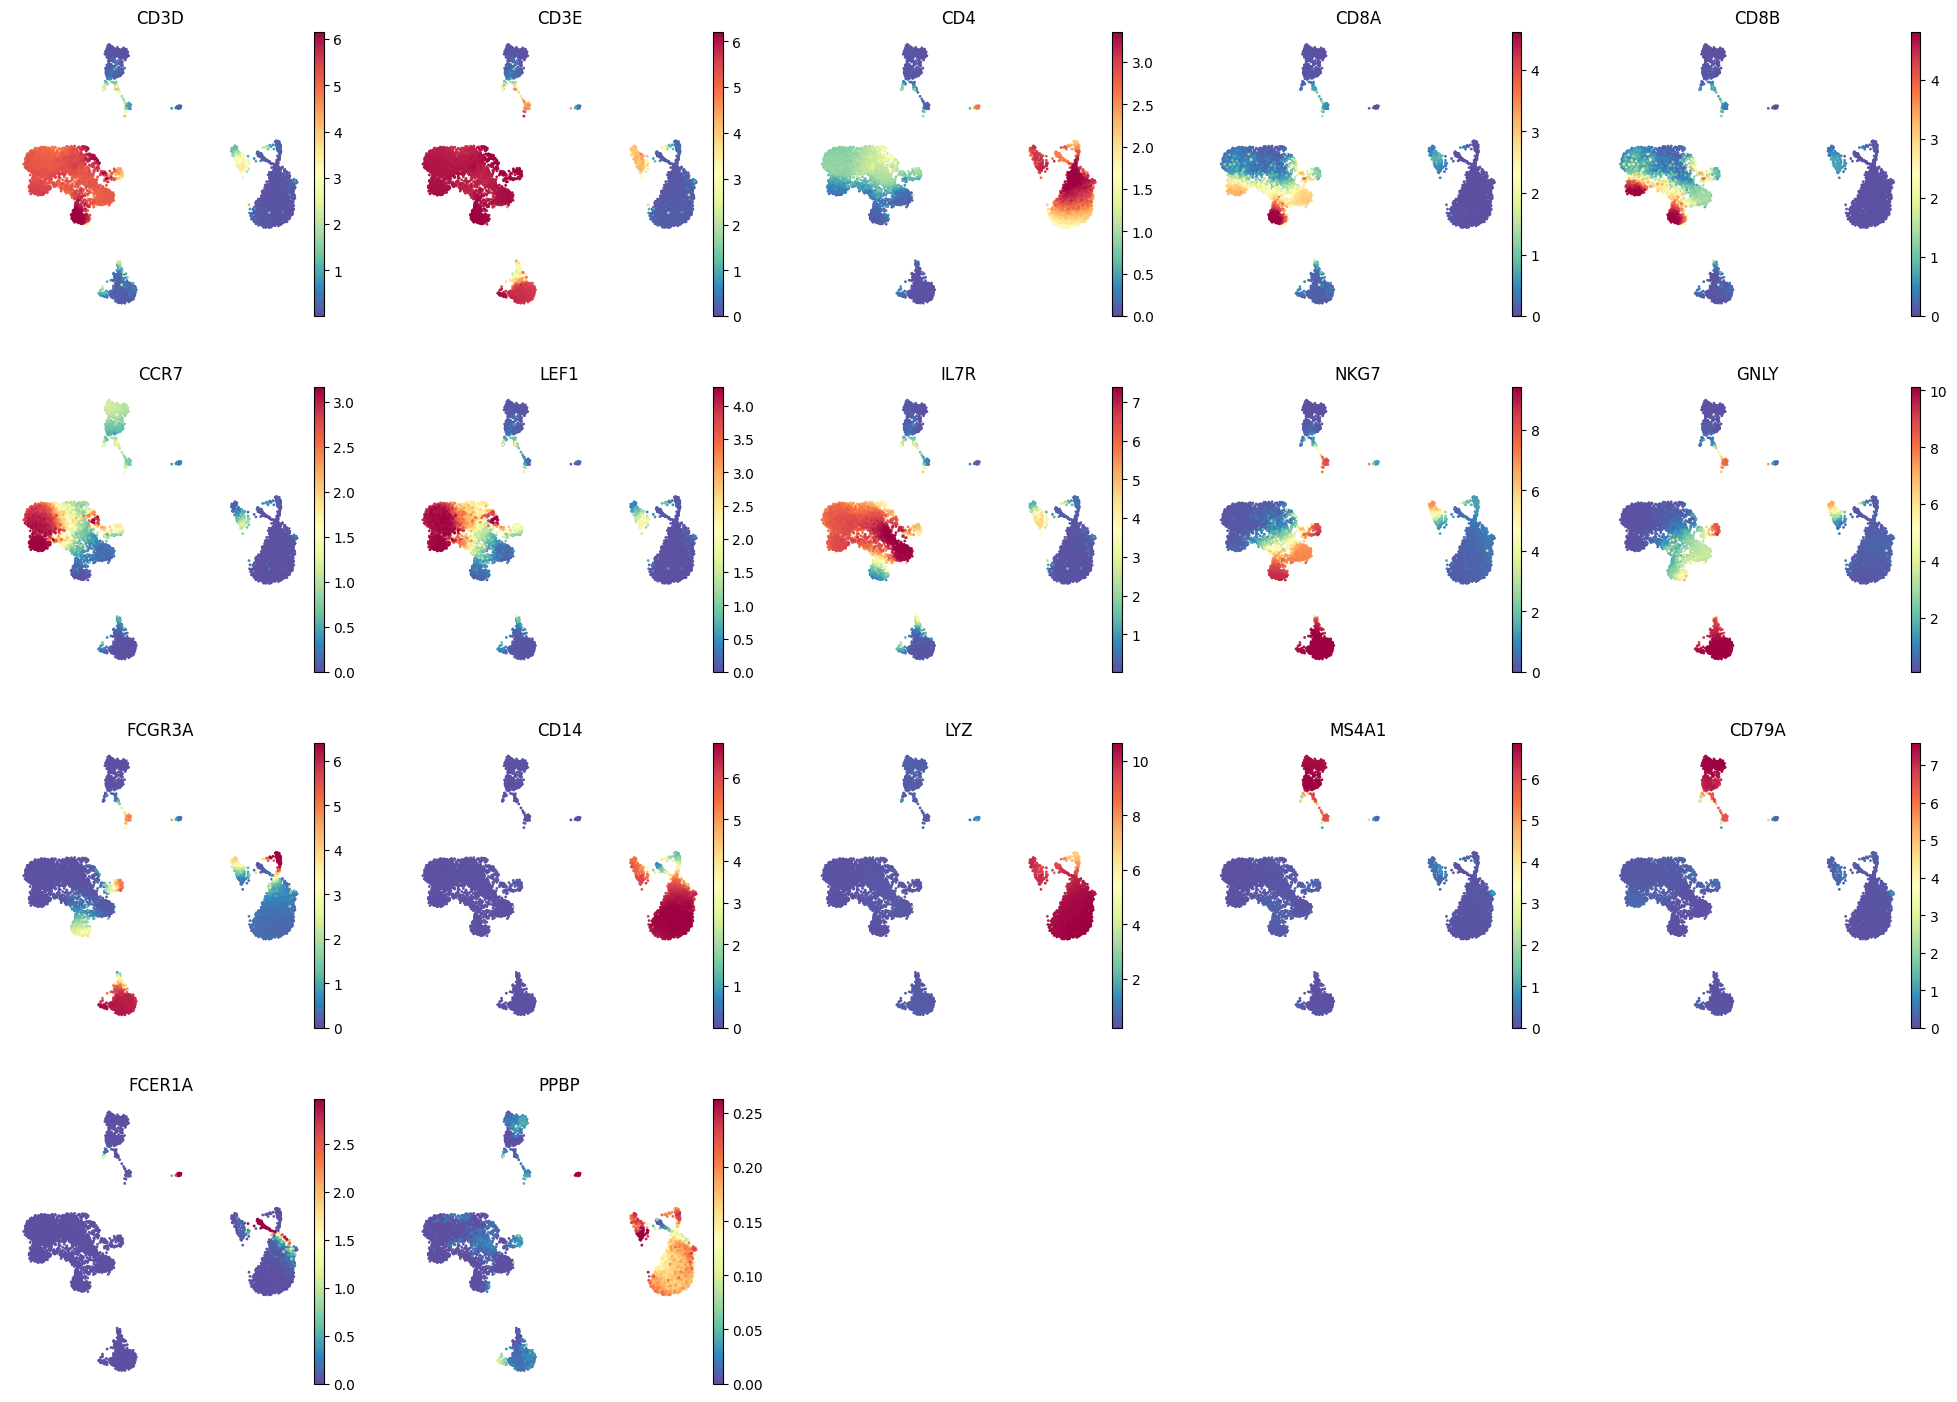

In [30]:
# Plot all markers (using imputed data for clearer visualization)
sc.pl.umap(
    adata,
    color=marker_genes.tolist(),
    layer="MAGIC_imputed_data",
    ncols=5,
    frameon=False,
    vmax="p99"  # Use 99th percentile for color scaling
)

### Compute Cell Type Signature Scores

Gene signature scores aggregate expression of multiple markers, providing a more robust signal than individual genes.

In [31]:
# Define cell type signatures (lists of marker genes)
signatures = {
    "T_cell": ["CD3D", "CD3E", "CCR7", "LEF1"],
    "CD4_T": ["CD4", "IL7R"],
    "CD8_T": ["CD8A", "CD8B"],
    "NK": ["NKG7", "GNLY", "FCGR3A"],
    "B_cell": ["MS4A1", "CD79A", "PAX5", "MME", "CD19", "IRF4"],
    "Monocyte": ["CD14", "LYZ", "TREM1"],
    "Progenitor": ["CD34"],
    "Erythrocyte": ["GATA1"],
    "Megakaryocyte": ["ITGA2B"],
    "Dendritic": ["IRF8"],
    "Neural": ["NCAM1"],
}

# Calculate signature scores
for name, genes in signatures.items():
    # Filter to genes present in dataset
    genes_present = [g for g in genes if g in adata.var_names]
    
    if len(genes_present) > 0:
        sc.tl.score_genes(
            adata,
            gene_list=genes_present,
            score_name=f"{name}_score",
            use_raw=False
        )
        print(f"Calculated {name}_score using {len(genes_present)} genes")

computing score 'T_cell_score'
    finished (0:00:00)
Calculated T_cell_score using 4 genes
computing score 'CD4_T_score'
    finished (0:00:00)
Calculated CD4_T_score using 2 genes
computing score 'CD8_T_score'
    finished (0:00:00)
Calculated CD8_T_score using 2 genes
computing score 'NK_score'
    finished (0:00:00)
Calculated NK_score using 3 genes
computing score 'B_cell_score'
    finished (0:00:00)
Calculated B_cell_score using 5 genes
computing score 'Monocyte_score'
    finished (0:00:00)
Calculated Monocyte_score using 3 genes
computing score 'Dendritic_score'
    finished (0:00:00)
Calculated Dendritic_score using 1 genes
computing score 'Neural_score'
    finished (0:00:00)
Calculated Neural_score using 1 genes


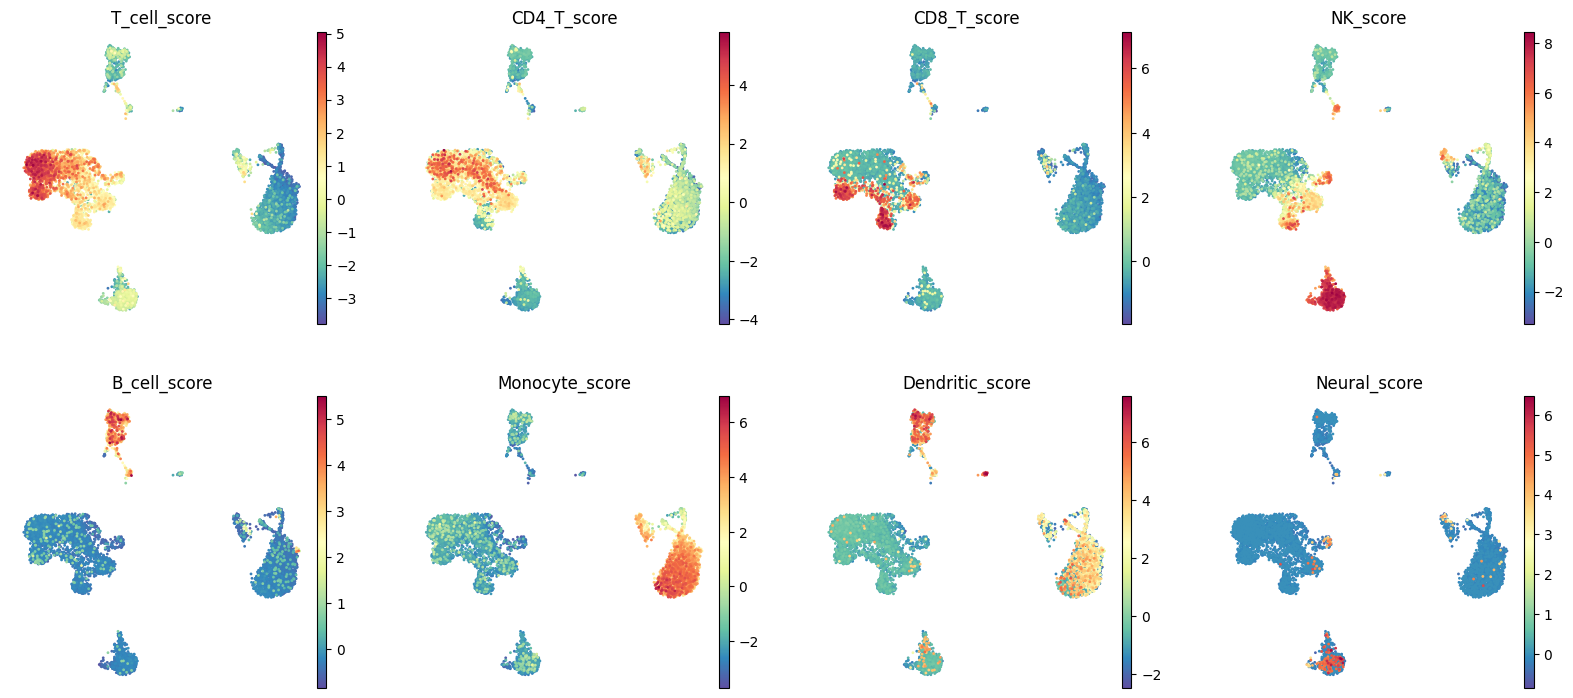

In [32]:
# Visualize signature scores
score_names = [f"{name}_score" for name in signatures.keys() if f"{name}_score" in adata.obs]
sc.pl.umap(adata, color=score_names, ncols=4, frameon=False)

### Annotate Clusters Based on Marker Expression

Examine which markers are enriched in each cluster to assign cell type labels.

**Note**: This mapping is specific to this dataset and should be adjusted based on your marker gene analysis.

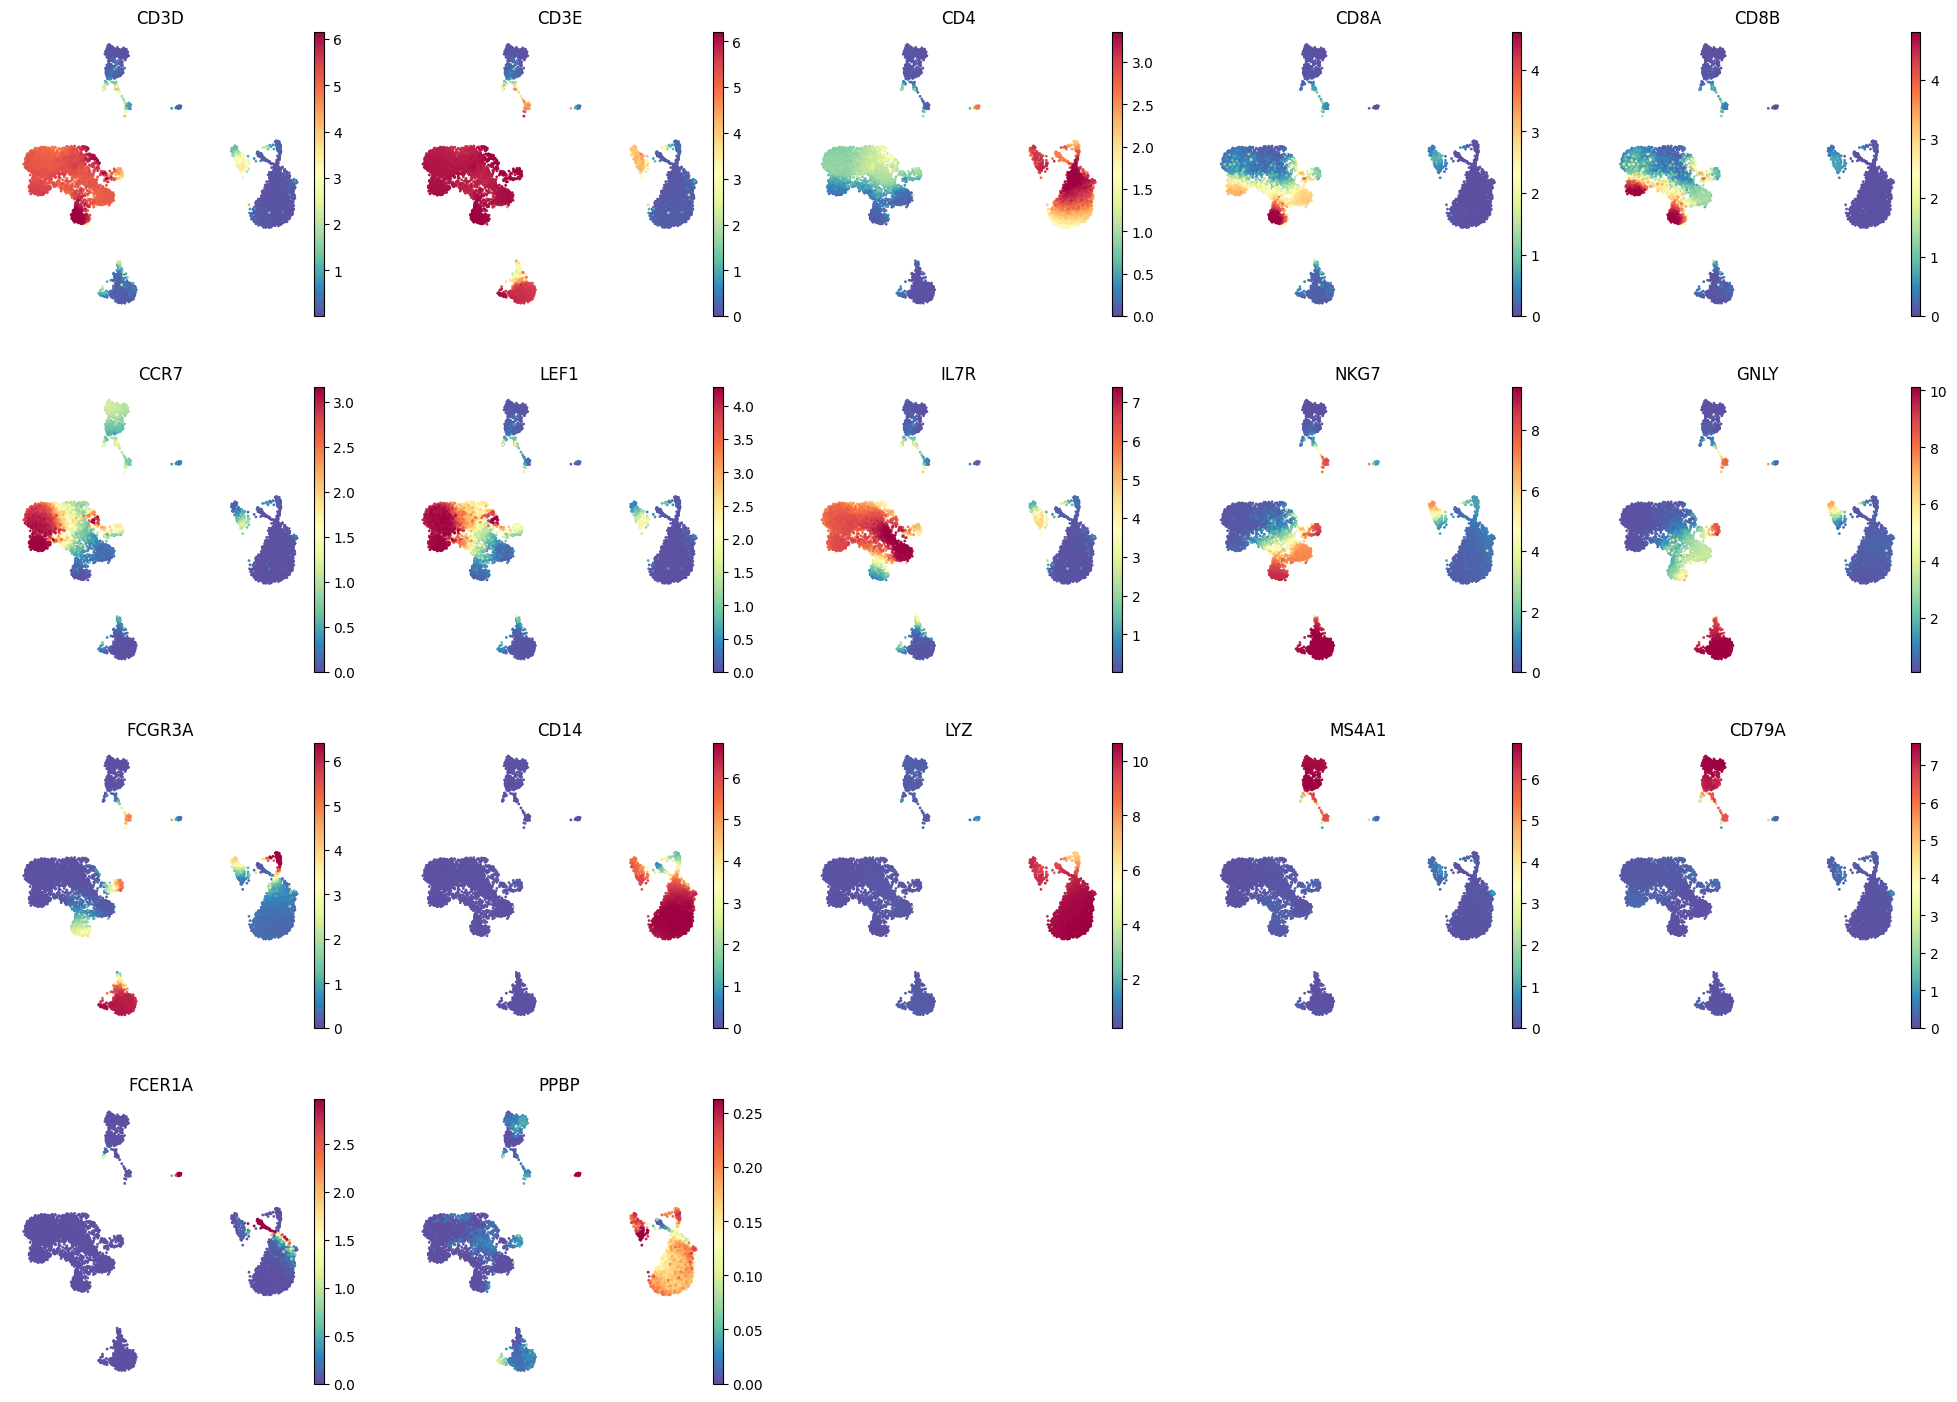

In [33]:
# Plot all markers (using imputed data for clearer visualization)
sc.pl.umap(
    adata,
    color=marker_genes.tolist(),
    layer="MAGIC_imputed_data",
    ncols=5,
    frameon=False,
    vmax="p99"  # Use 99th percentile for color scaling
)

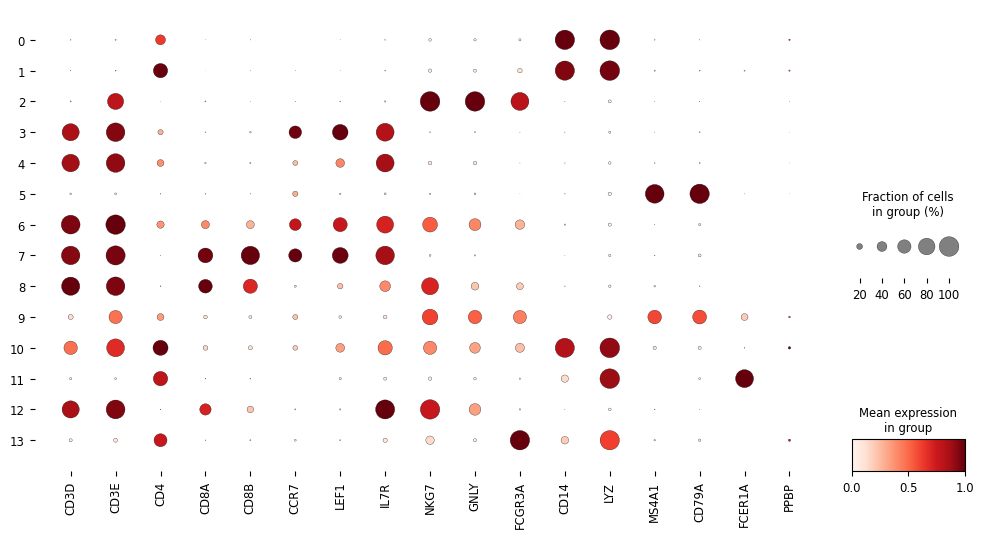

In [34]:
# Create a dotplot to see marker enrichment per cluster
sc.pl.dotplot(
    adata,
    var_names=marker_genes.tolist(),
    groupby="leiden",
    standard_scale="var",  # Normalize per gene
    figsize=(12, 6)
)

### Assign Cell Type Labels

Based on the marker expression patterns above, we manually annotate clusters.

**⚠️ Important**: This mapping is dataset-specific and should be carefully validated!

Cell type annotations:
cell_type
CD4 T cells 1       1296
CD4 T cells 2       1088
CD14 Monocytes 1    1050
NK cells 1          1049
CD14 Monocytes 2     743
pro B cells 2        555
CD8 T cells 1        454
CD8 T cells 3        453
CD8 T cells 2        381
Doublets             159
pDC                   92
pro B cells 1         73
Dendritic cells       71
Name: count, dtype: int64


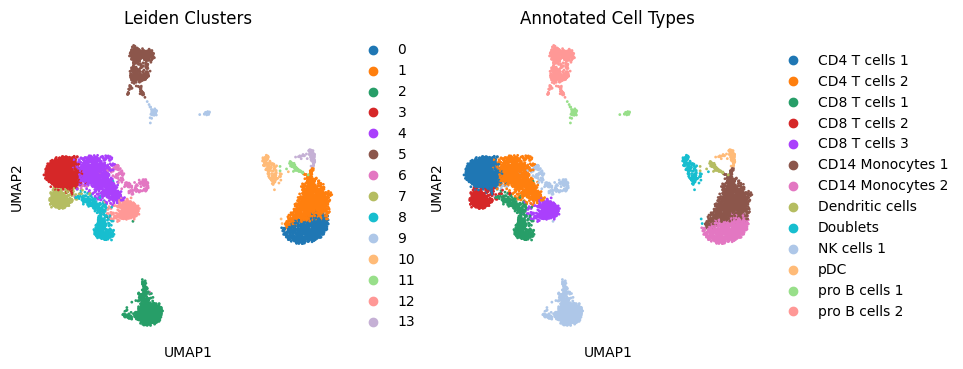

In [35]:
# Example mapping (ADJUST based on your results!)
leiden_to_celltype = {
    "0": "CD14 Monocytes 2",
    "1": "CD14 Monocytes 1",
    "2": "NK cells 1",
    "3": "CD4 T cells 1",
    "4": "CD4 T cells 2",
    "5": "pro B cells 2",
    "6": "NK cells 1",
    "7": "CD8 T cells 2",
    "8": "CD8 T cells 1",
    "9": "pro B cells 1",
    "10": "Doublets",
    "11": "Dendritic cells",
    "12": "CD8 T cells 3",
    "13": "pDC",
    # Add more as needed based on your cluster numbers
}

# Apply mapping
adata.obs["cell_type"] = adata.obs["leiden"].map(leiden_to_celltype)

# Fill any unmapped clusters with "Unknown"
adata.obs["cell_type"] = adata.obs["cell_type"].fillna("Unknown")

print("Cell type annotations:")
print(adata.obs["cell_type"].value_counts())
sc.pl.umap(adata, color=["leiden", "cell_type"], title=["Leiden Clusters", "Annotated Cell Types"])

---

# 10. Quality Control Visualization

Let's examine how our QC metrics relate to the identified cell types.

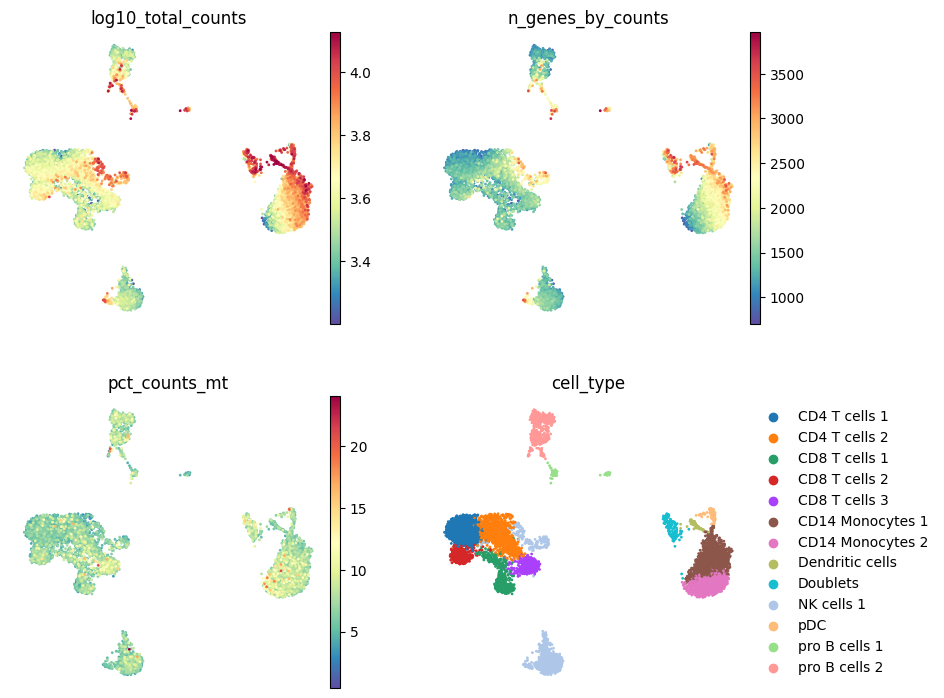

In [36]:
# Visualize QC metrics on UMAP
sc.pl.umap(
    adata,
    color=["log10_total_counts", "n_genes_by_counts", "pct_counts_mt", "cell_type"],
    ncols=2,
    frameon=False
)

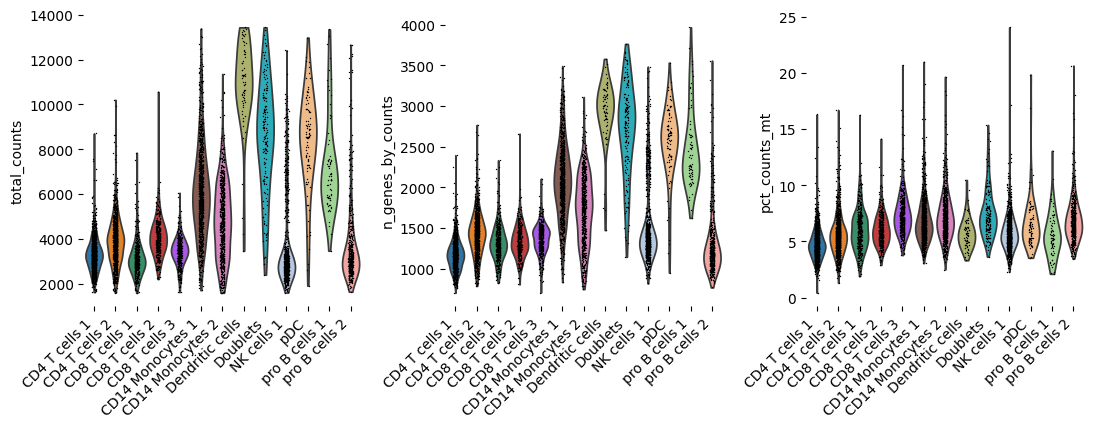

In [37]:
# right align for better readability of rotated x-labels
matplotlib.rcParams["xtick.alignment"] = "right"

sc.pl.violin(
    adata,
    keys=["total_counts", "n_genes_by_counts", "pct_counts_mt"],
    groupby="cell_type",
    rotation=45
)

# restore the default (center alignment) so later plots look normal
matplotlib.rcParams["xtick.alignment"] = "center"

---

# 11. Save Processed Data

Save the fully processed AnnData object for future analysis.

**What's saved**:
- All count layers (raw, normalized, log-transformed, imputed)
- All dimensionality reductions (PCA, UMAP, diffusion maps)
- All annotations (clusters, cell types, QC metrics)
- Processing parameters in `.uns`

In [38]:
# Save full processed dataset
adata.write(output_h5ad_file)
print(f"✓ Saved processed data to: {output_h5ad_file}")

# Optional: Create a lighter version for sharing
adata_light = adata.copy()

# Remove large matrices that can be recomputed
if "MAGIC_imputed_data" in adata_light.layers:
    del adata_light.layers["MAGIC_imputed_data"]
if "DM_Kernel" in adata_light.obsp:
    del adata_light.obsp["DM_Kernel"]

# Save lightweight version
light_output = output_h5ad_file.replace(".h5ad", "_light.h5ad")
adata_light.write(light_output)
print(f"✓ Saved lightweight version to: {light_output}")

✓ Saved processed data to: data/pbmc_10x_rna_processed.h5ad
✓ Saved lightweight version to: data/pbmc_10x_rna_processed_light.h5ad


---

# Next Steps and Advanced Analyses

Your processed dataset is now ready for advanced analyses:

## 1. Differential Expression Analysis
```python
# Find marker genes for each cell type
sc.tl.rank_genes_groups(adata, groupby='cell_type', method='wilcoxon')
sc.pl.rank_genes_groups(adata, n_genes=20)
```

**📖 Reference**: [Differential expression](https://www.sc-best-practices.org/conditions/differential_gene_expression.html)

## 2. Trajectory Inference with Palantir

Palantir models cellular differentiation and fate decisions using diffusion maps. It's particularly powerful for:
- Continuous pseudotime assignment
- Identifying branch points in differentiation
- Computing differentiation potential
- Terminal state probabilities

```python
import palantir

# Identify an early progenitor cell as the start cell
# (you'd pick this based on marker expression)
start_cell = adata.obs_names[0]  # Replace with actual early cell

# Run Palantir pseudotime
pr_res = palantir.core.run_palantir(
    adata, 
    start_cell=start_cell,
)


# Visualize pseudotime on UMAP
sc.pl.umap(adata, color=['palantir_pseudotime', 'palantir_entropy'])
```

**📖 References**: 
- [Palantir documentation](https://palantir.readthedocs.io/)
- Setty et al. (2019). *Nature Biotechnology*. [Characterization of cell fate probabilities in single-cell data with Palantir](https://doi.org/10.1038/s41587-019-0068-4)

## 3. Gene Set Enrichment
```python
# Pathway enrichment analysis
import gseapy as gp
# ... enrichment analysis code
```

## 4. Integration with Other Datasets
```python
import scvi
# Batch correction and integration
```

**📖 Reference**: [Data integration](https://www.sc-best-practices.org/cellular_structure/integration.html)

## 5. Multi-omics Analysis
For datasets with RNA + ATAC or protein measurements:
```python
import muon as mu
# Multi-modal analysis
```

**📖 Reference**: [Multimodal analysis](https://muon.readthedocs.io/en/latest/omics/uni.html)

---

# Resources and Further Reading

## Essential References

1. **Single-cell best practices book**  
   Comprehensive guide covering all aspects of single-cell analysis  
   [https://www.sc-best-practices.org/](https://www.sc-best-practices.org/)

2. **Single-cell primers repository**  
   Additional tutorials and example workflows  
   [https://github.com/settylab/single-cell-primers](https://github.com/settylab/single-cell-primers)

3. **Scanpy tutorials**  
   Official Scanpy documentation and tutorials  
   [https://scanpy-tutorials.readthedocs.io/](https://scanpy-tutorials.readthedocs.io/)

4. **scverse ecosystem**  
   Explore other tools for specialized analyses  
   [https://scverse.org/](https://scverse.org/)

## Key Papers

- **Scanpy**: Wolf et al. (2018). *Genome Biology*. [DOI:10.1186/s13059-017-1382-0](https://doi.org/10.1186/s13059-017-1382-0)
- **AnnData**: Virshup et al. (2021). *bioRxiv*. [DOI:10.1101/2021.12.16.473007](https://doi.org/10.1101/2021.12.16.473007)
- **Leiden clustering**: Traag et al. (2019). *Scientific Reports*. [DOI:10.1038/s41598-019-41695-z](https://doi.org/10.1038/s41598-019-41695-z)
- **UMAP**: McInnes et al. (2018). *arXiv*. [arXiv:1802.03426](https://arxiv.org/abs/1802.03426)
- **Scrublet**: Wolock et al. (2019). *Cell Systems*. [DOI:10.1016/j.cels.2018.11.005](https://doi.org/10.1016/j.cels.2018.11.005)

## Getting Help

- **scverse Discourse**: [https://discourse.scverse.org/](https://discourse.scverse.org/)
- **Scanpy GitHub**: [https://github.com/scverse/scanpy](https://github.com/scverse/scanpy)
- **Stack Overflow**: Tag your questions with `scanpy` or `single-cell`

---

# Summary

In this tutorial, we performed a complete single-cell RNA-seq analysis workflow:

✅ **Quality Control**: Filtered low-quality cells based on UMI counts, gene counts, and mitochondrial content  
✅ **Normalization**: Library size normalization and log-transformation  
✅ **Feature Selection**: Identified 2,500 highly variable genes  
✅ **Dimensionality Reduction**: PCA, UMAP, and diffusion maps  
✅ **Clustering**: Leiden clustering to identify cell groups  
✅ **Doublet Detection**: Identified potential doublets with Scrublet  
✅ **Imputation**: MAGIC imputation for visualization  
✅ **Cell Type Annotation**: Assigned biological identities using marker genes  

**Key Takeaways**:
- Follow best practices from the community (sc-best-practices.org)
- Use appropriate QC thresholds for your specific dataset
- Validate cell type annotations with multiple marker genes
- Save intermediate processing steps for reproducibility
- Be cautious with imputed data (visualization only!)

**Remember**: Parameter tuning is essential! What works for this PBMC dataset may need adjustment for your specific data.